In [1]:
train_dir = r"C:\Users\Sharayu\Desktop\brain_tumor_project\Brain Tumor MRI Dataset\Training"
test_dir  = r"C:\Users\Sharayu\Desktop\brain_tumor_project\Brain Tumor MRI Dataset\Testing"

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageEnhance
from sklearn.utils import shuffle  # [web:138]
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from tensorflow.keras.preprocessing.image import load_img, img_to_array  # [web:106]
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16


In [3]:
# Load and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):  # [web:133]
    label_dir = os.path.join(train_dir, label)
    if not os.path.isdir(label_dir):
        continue
    for image_name in os.listdir(label_dir):
        train_paths.append(os.path.join(label_dir, image_name))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels, random_state=42)

# Load and shuffle the test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    label_dir = os.path.join(test_dir, label)
    if not os.path.isdir(label_dir):
        continue
    for image_name in os.listdir(label_dir):
        test_paths.append(os.path.join(label_dir, image_name))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels, random_state=42)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Sharayu\\Desktop\\brain_tumor_project\\Brain Tumor MRI Dataset\\Training'

In [4]:
import os

base = r"C:\Users\Sharayu\Desktop\brain_tumor_project"
print(os.listdir(base))


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Sharayu\\Desktop\\brain_tumor_project'

In [5]:
import os
print(os.getcwd())


C:\Users\shara\OneDrive\Desktop\brain_tumor_project


In [6]:
base = r"C:\Users\shara\OneDrive\Desktop\brain_tumor_project"
print(os.listdir(base))


['.ipynb_checkpoints', 'app', 'app.py', 'Brain Tumor MRI Dataset', 'brain_tumor_vgg16.ipynb', 'Glioma.jpg', 'mri_brain_tumor_detection.ipynb', 'Report_10.pdf', 'Te-gl_0010.jpg', 'templates', 'uploaded_image.png']


In [7]:
train_dir = base + r"\Brain Tumor MRI Dataset\Training"
test_dir  = base + r"\Brain Tumor MRI Dataset\Testing"


In [8]:
import os

print("Train dir exists:", os.path.isdir(train_dir))
print("Test dir exists :", os.path.isdir(test_dir))
print("Train classes  :", os.listdir(train_dir))


Train dir exists: True
Test dir exists : True
Train classes  : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
from sklearn.utils import shuffle

# Train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    label_dir = os.path.join(train_dir, label)
    if not os.path.isdir(label_dir):
        continue
    for image_name in os.listdir(label_dir):
        train_paths.append(os.path.join(label_dir, image_name))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels, random_state=42)

# Test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    label_dir = os.path.join(test_dir, label)
    if not os.path.isdir(label_dir):
        continue
    for image_name in os.listdir(label_dir):
        test_paths.append(os.path.join(label_dir, image_name))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels, random_state=42)

print("Train images:", len(train_paths))
print("Test images :", len(test_paths))


Train images: 5712
Test images : 1311


In [10]:
IMAGE_SIZE = 128

def augment_image(image):
    from PIL import ImageEnhance, Image
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

def open_images(paths):
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = augment_image(img)
        images.append(img)
    return np.array(images)

def encode_label(labels):
    unique_labels = os.listdir(train_dir)
    unique_labels = [l for l in unique_labels
                     if os.path.isdir(os.path.join(train_dir, l))]
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

def datagen(paths, labels, batch_size=20, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels


In [11]:
base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

num_classes = len(os.listdir(train_dir))

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

epochs = 5
steps = len(train_paths) // 20

history = model.fit(
    datagen(train_paths, train_labels, batch_size=20, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps
)


Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 223s 774ms/step - loss: 0.4470 - sparse_categorical_accuracy: 0.8260
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 550s 2s/step - loss: 0.2292 - sparse_categorical_accuracy: 0.9132   
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - loss: 0.1660 - sparse_categorical_accuracy: 0.9373   
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 229s 804ms/step - loss: 0.1127 - sparse_categorical_accuracy: 0.9585
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 236s 827ms/step - loss: 0.0757 - sparse_categorical_accuracy: 0.9707


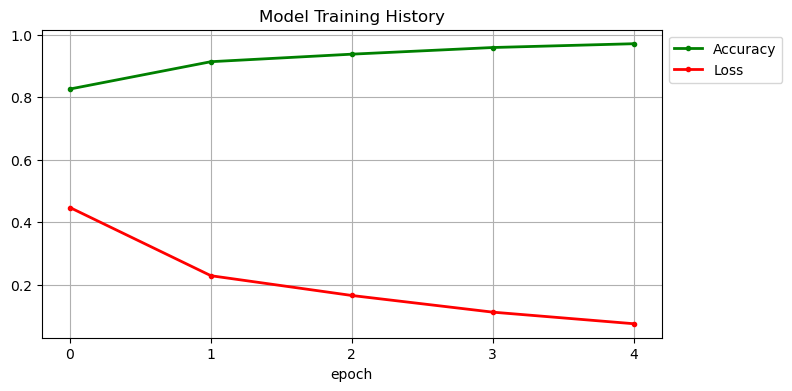

In [12]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks(range(epochs))
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [13]:
# load and preprocess test set
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

# predictions
test_predictions = model.predict(test_images)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(test_labels_encoded,
                            np.argmax(test_predictions, axis=1)))


41/41 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       300
           1       0.91      0.93      0.92       306
           2       1.00      1.00      1.00       405
           3       0.97      0.99      0.98       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



In [14]:
model.save('mri_brain_tumor_vgg16.h5')

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load and preprocess all test images
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

# Predict
test_predictions = model.predict(test_images)

# Classification report
print("Classification Report:")
print(classification_report(test_labels_encoded,
                            np.argmax(test_predictions, axis=1)))  # [web:162]


41/41 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       300
           1       0.92      0.93      0.93       306
           2       1.00      1.00      1.00       405
           3       0.97      0.99      0.98       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



Confusion Matrix:
[[276  21   2   1]
 [ 12 285   0   9]
 [  0   0 405   0]
 [  0   3   0 297]]


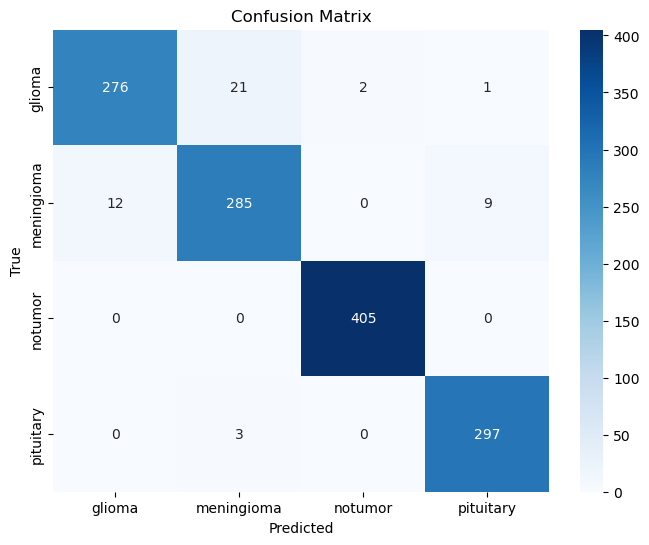

In [16]:
conf_matrix = confusion_matrix(test_labels_encoded,
                               np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

class_names = os.listdir(train_dir)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [17]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array  # [web:106]

class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    img = load_img(img_path, target_size=(image_size, image_size))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    idx = np.argmax(preds, axis=1)[0]
    conf = float(np.max(preds) * 100)

    label = class_labels[idx]
    result = "No Tumor" if label == 'notumor' else f"Tumor: {label}"

    plt.imshow(load_img(img_path))
    plt.axis('off')
    plt.title(f"{result} (Confidence: {conf:.2f}%)")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


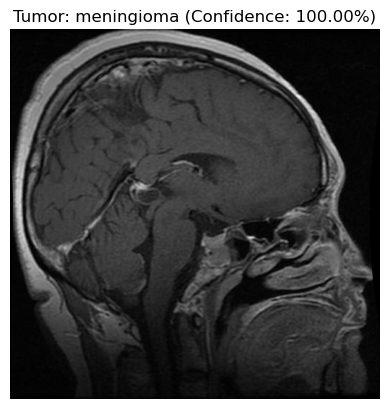

In [18]:
img_path = test_paths[0]
detect_and_display(img_path, model)

In [1]:
import os

train_dir = r"C:\Users\Sharayu\Desktop\brain_tumor_project\Brain Tumor MRI Dataset\Training"
unique_labels = os.listdir(train_dir)
print(unique_labels)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Sharayu\\Desktop\\brain_tumor_project\\Brain Tumor MRI Dataset\\Training'

In [3]:
import os

train_dir = r"Brain Tumor MRI Dataset\Training"  # your actual train_dir path
unique_labels = os.listdir(train_dir)
print(unique_labels)

['glioma', 'meningioma', 'notumor', 'pituitary']
